In [1]:
include("../resk.jl")

RESK successfully loaded.


In [2]:
TEST_N = 10
thread_times = Array{Float64}(undef,TEST_N)

for j in 1:TEST_N
    procs = addprocs(j)
    @everywhere include("../resk.jl")

    temp_res, thread_times[j] = @timed rangeexp_1d(10,20,10;distributed=true)
    rmprocs(2:TEST_N...)
end

RESK successfully loaded.
      From worker 2:	RESK successfully loaded.
RESK successfully loaded.
      From worker 4:	RESK successfully loaded.
      From worker 3:	RESK successfully loaded.
RESK successfully loaded.
      From worker 7:	RESK successfully loaded.
      From worker 6:	RESK successfully loaded.
      From worker 5:	RESK successfully loaded.
RESK successfully loaded.
      From worker 9:	RESK successfully loaded.
      From worker 10:	RESK successfully loaded.
      From worker 8:	RESK successfully loaded.
      From worker 11:	RESK successfully loaded.
RESK successfully loaded.
      From worker 11:	RESK successfully loaded.
      From worker 15:	RESK successfully loaded.
      From worker 16:	RESK successfully loaded.
      From worker 14:	RESK successfully loaded.
      From worker 12:	RESK successfully loaded.
      From worker 13:	RESK successfully loaded.
RESK successfully loaded.
      From worker 13:	RESK successfully loaded.
      From worker 11:	RESK successfu

In [1]:
#Plots.bar(nothread_times,label="without 'distributed' option")
Plots.bar(thread_times,ylabel="Simulation time (s)",size=(800,570),ylims=(0,120),xlabel="Number of processes",label="using 'distributed' option",title="Difference in simulation time between a single \n process and distributed processing in rangeexp_1d (8 iterates)")

UndefVarError: UndefVarError: `Plots` not defined

That is the main result we wanted to see in this short example.

Finally, let's just confirm that our simulations are working and non-trivial:

In [ ]:
temp_res = rangeexp_1d(50,50,4;distributed=true)

┌ Info: Saved animation to C:\Users\Hartree\AppData\Local\Temp\jl_IVc1SduFch.gif
└ @ Plots C:\Users\Hartree\.julia\packages\Plots\ju9dp\src\animation.jl:156


Plots.AnimatedGif("C:\\Users\\Hartree\\AppData\\Local\\Temp\\jl_IVc1SduFch.gif")
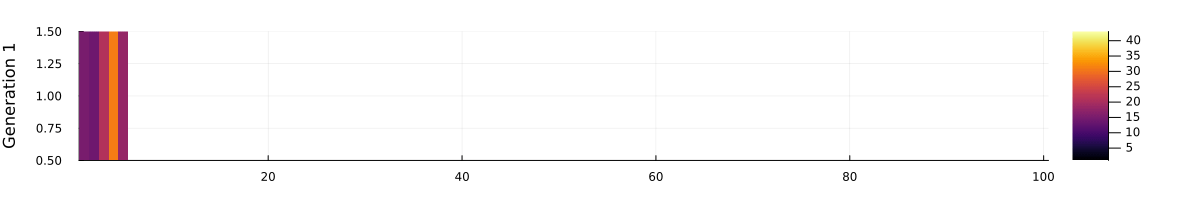

In [3]:
re_heatmap(temp_res["pops"][:,:,2],1,50,70;n_gens_sub=50)